## Visualization of Plant Connectivity

In [27]:
import os
import sys
import numpy as np
# load files for each season
import pickle
import pandas as pd
sys.path.append('../scripts')
from utils import average_across_days

# Choose Ecosystem and Metric
ecosystem = 'LaurentianMapleGrove'  # 'GulfStLawrence', 'LaurentianMapleGrove'
metric = 'transfer_entropy'  # 'PLV', 'coherence', 'transfer_entropy', 'wpli', 'imag_coherence'

if ecosystem == 'GulfStLawrence':
    from GulfStLawrence_info import seasons, SPRING, SUMMER, FALL, WINTER, plant_common_names
else:
    from LaurentianMapleGrove_info import seasons, SPRING, SUMMER, FALL, WINTER, plant_common_names

df_all_seasons = []
for SEASON in [SPRING, SUMMER, FALL, WINTER]:
    try:
        with open(f'../plant_data_{ecosystem}/{seasons[SEASON]}/connectivity_results_{metric}.pkl', 'rb') as f:
            dfs_results = pickle.load(f)
            df_combined, df_avg = average_across_days(dfs_results, metric=metric)
            df_avg["Season"] = SEASON
            df_all_seasons.append(df_avg)
    except FileNotFoundError:
        print(f"File not found for season {seasons[SEASON]}. Skipping...")
        continue

# Sum transfer entropy at each epoch for each season
df_all_seasons_combined = pd.concat(df_all_seasons, ignore_index=True)

# Convert epochs to hours
total_epochs = df_all_seasons_combined["Epoch"].max() + 1  # Assuming epochs span 24 hours
df_all_seasons_combined["Hour"] = df_all_seasons_combined["Epoch"] / total_epochs * 24

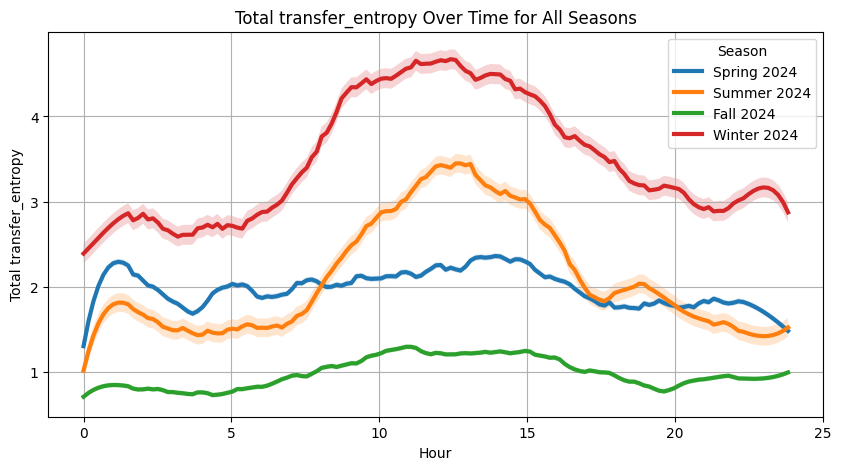

In [9]:
from scipy.signal import savgol_filter
import numpy as np
import matplotlib.pyplot as plt

# Convert epochs to hours
total_epochs = df_all_seasons_combined["Epoch"].max() + 1  # Assuming epochs span 24 hours
df_all_seasons_combined["Hour"] = df_all_seasons_combined["Epoch"] / total_epochs * 24
df_avg = df_all_seasons_combined.groupby(["Epoch", "Plant1", "Plant2", 'Season'], as_index=False)[metric].mean()
# Plot transfer entropy over time for each season with CI
plt.figure(figsize=(10, 5))
for season in df_all_seasons_combined["Season"].unique():
    df_season = df_all_seasons_combined[df_all_seasons_combined["Season"] == season]
    df_epoch = df_season.groupby("Epoch")[metric].sum()
    
    # Apply Savitzky-Golay filter for smoothing
    smoothed_entropy = savgol_filter(df_epoch.values, window_length=20, polyorder=3)
    
    # Calculate 95% CI
    ci = 1.96 * np.std(smoothed_entropy) / np.sqrt(len(smoothed_entropy))
    lower_bound = smoothed_entropy - ci
    upper_bound = smoothed_entropy + ci
    
    plt.plot(df_epoch.index / total_epochs * 24, smoothed_entropy, linestyle="-", label=seasons[season], linewidth=3)
    plt.fill_between(df_epoch.index / total_epochs * 24, lower_bound, upper_bound, alpha=0.2)

plt.xlabel("Hour")
plt.ylabel(f"Total {metric}")
plt.title(f"Total {metric} Over Time for All Seasons")
plt.legend(title="Season")
plt.grid()
plt.show()


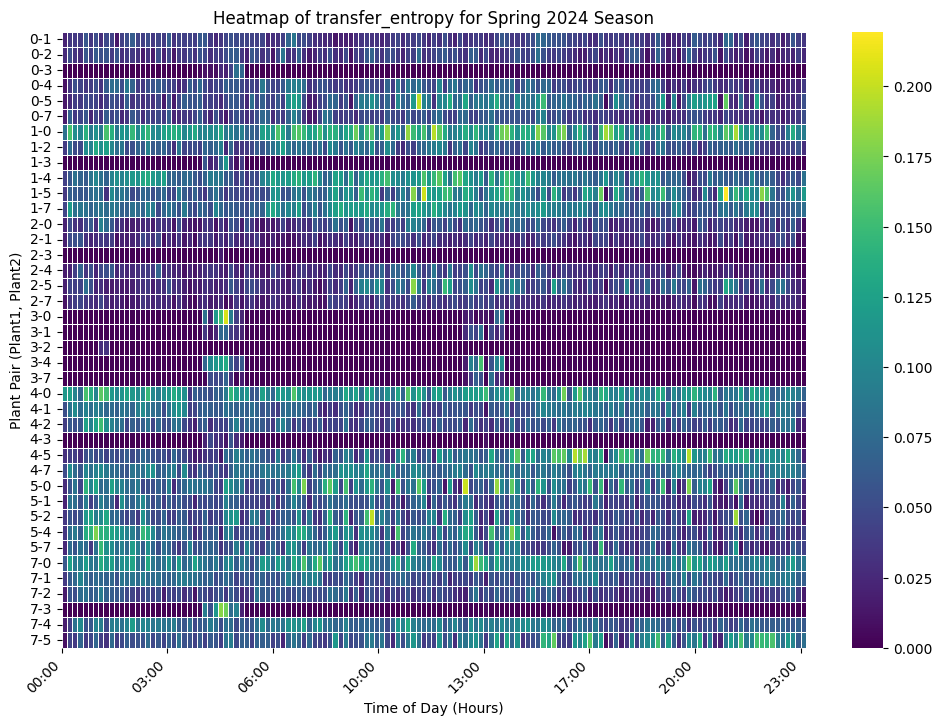

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the season to plot
season = SPRING

# Reset index to convert MultiIndex into columns for easier plotting
df_plot = df_avg.reset_index()
# select one season
df_plot = df_plot[df_plot['Season'] == season]

# Get the total number of epochs
total_epochs = df_plot["Epoch"].max() + 1  # Assuming epochs span 24 hours
df_plot["Hour"] = df_plot["Epoch"] / total_epochs * 24  # Convert epochs to hours

# Pivot table for heatmap
pivot_table = df_plot.pivot(index=["Plant1", "Plant2"], columns="Hour", values=metric)

# Define color scale range
y_min = 0
y_max = np.max(pivot_table.values)  # Set max value for color scale

# Create heatmap with better spacing
plt.figure(figsize=(12, 8))
ax = sns.heatmap(pivot_table, cmap="viridis", annot=False, linewidths=0.5, vmin=y_min, vmax=y_max)

# Format x-axis labels to properly span the full range
plt.xlabel("Time of Day (Hours)")
plt.ylabel("Plant Pair (Plant1, Plant2)")
plt.title(f"Heatmap of {metric} for {seasons[season]} Season")

# **Fix time labels across 142 epochs**  
num_ticks = 8  # Set a reasonable number of labels (adjust if needed)
time_ticks = np.linspace(0, total_epochs - 1, num_ticks)  # Spread labels evenly
time_labels = [f"{int(hour):02d}:00" for hour in (time_ticks / total_epochs * 24)]  # Convert back to hours

# Apply new time labels
plt.xticks(ticks=time_ticks, labels=time_labels, rotation=45, ha="right")

# Show plot
plt.show()


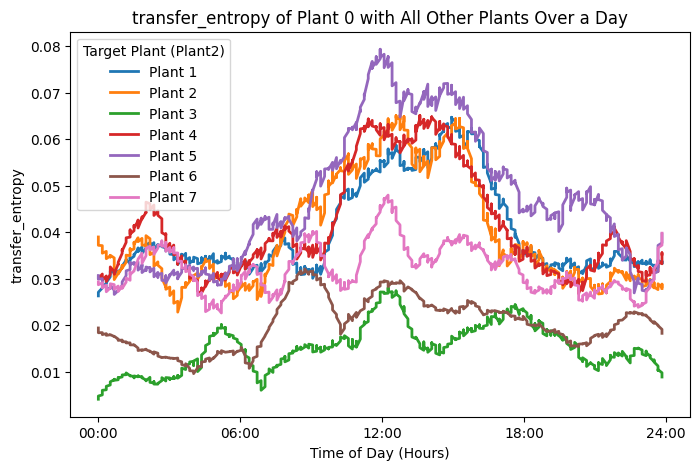

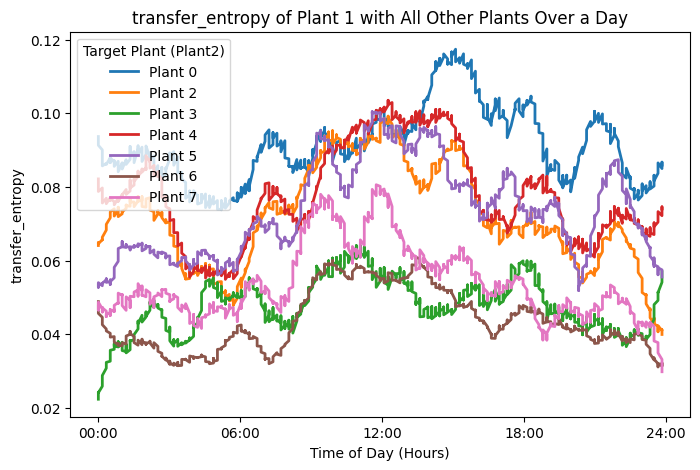

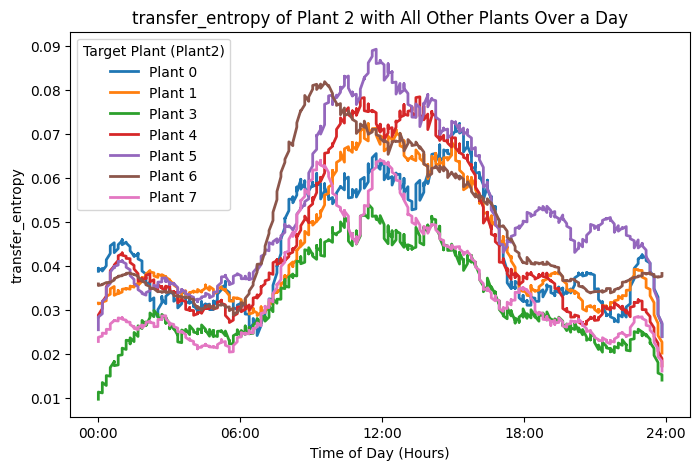

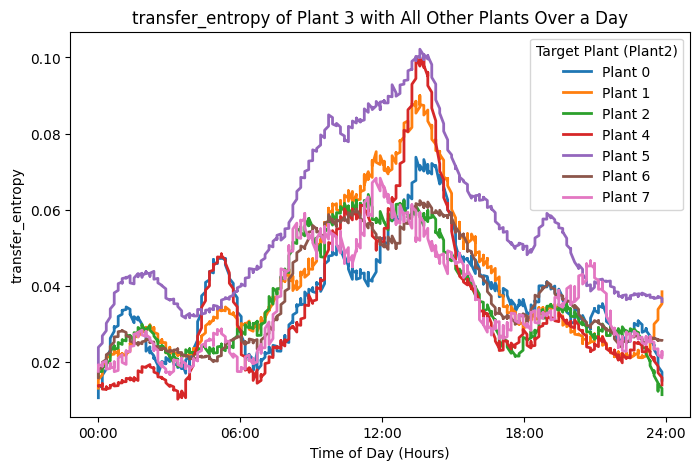

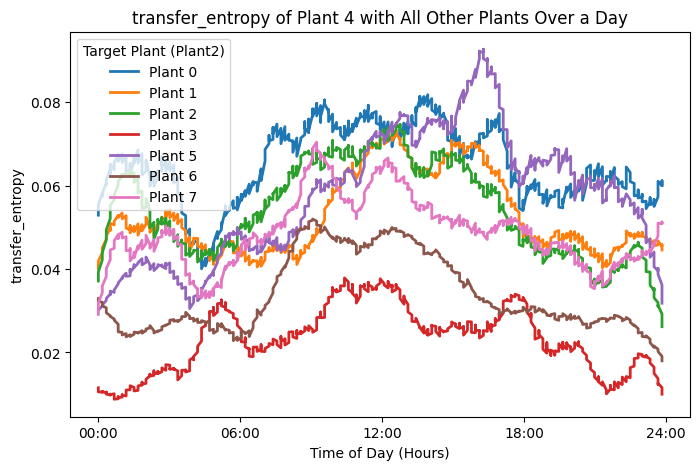

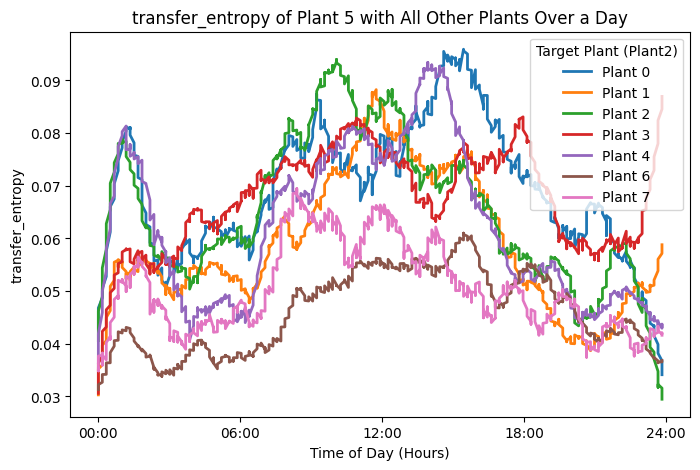

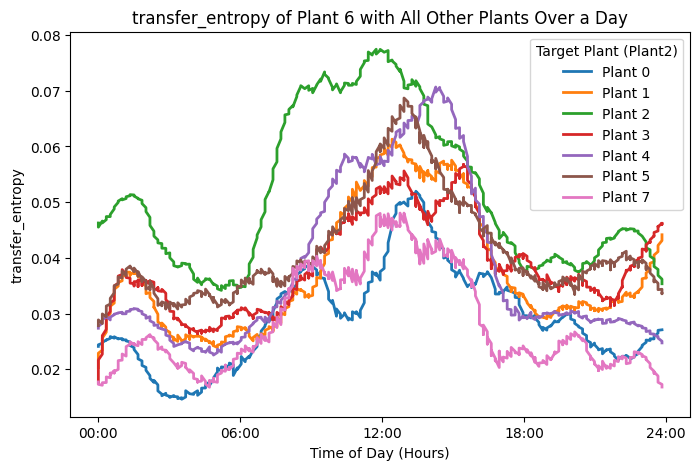

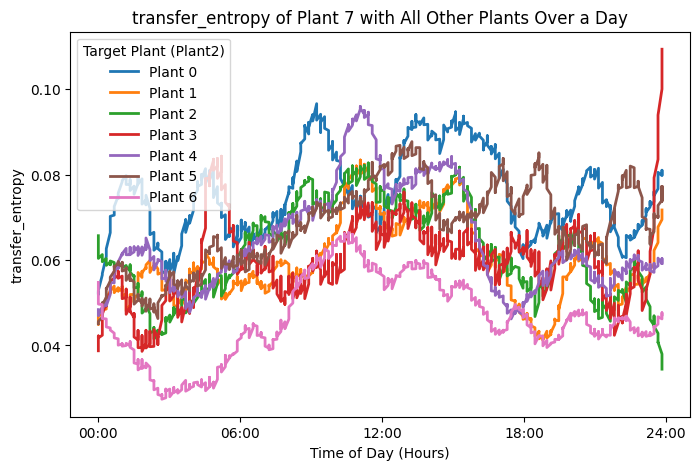

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter  # Import Savitzky-Golay filter

# Reset index to convert MultiIndex into columns for easier plotting
df_plot = df_avg.reset_index()

# Convert "Epoch" to hours of the day (assuming epochs are evenly spaced over 24 hours)
total_epochs = df_plot["Epoch"].max() + 1  # Number of epochs in a full day
df_plot["Hour"] = df_plot["Epoch"] / total_epochs * 24  # Scale to hours (0-24)

# Set smoothing parameters (adjust these for desired smoothness)
window_length = 50  # Must be an odd number (increase for more smoothing)
polyorder = 3  # Degree of polynomial (higher for more flexible fitting)

# Get unique plants
plants = df_plot["Plant1"].unique()

# Generate one plot per plant
for plant in plants:
    plt.figure(figsize=(8, 5))  # Create a new figure for each plant
    
    # Subset data for the specific plant
    subset = df_plot[df_plot["Plant1"] == plant]
    
    # Apply smoothing for each "Plant2" separately
    for plant2 in subset["Plant2"].unique():
        subset_p2 = subset[subset["Plant2"] == plant2].sort_values(by="Hour")  # Sort by time
        
        # Apply Savitzky-Golay filter for smoothness
        smoothed_entropy = savgol_filter(subset_p2[metric], window_length, polyorder, mode="nearest")
        
        # Plot smoothed data
        plt.plot(subset_p2["Hour"], smoothed_entropy, label=f"Plant {plant2}", linewidth=2)

    # Set labels and title
    plt.xlabel("Time of Day (Hours)")
    plt.ylabel(metric)
    plt.title(f"{metric} of Plant {plant} with All Other Plants Over a Day")
    
    # Customize x-axis ticks to show specific times (e.g., 0, 6, 12, 18, 24)
    plt.xticks(np.arange(0, 25, 6), labels=["00:00", "06:00", "12:00", "18:00", "24:00"])
    
    # Add legend
    plt.legend(title="Target Plant (Plant2)")

    # Show the plot for each plant
    plt.show()


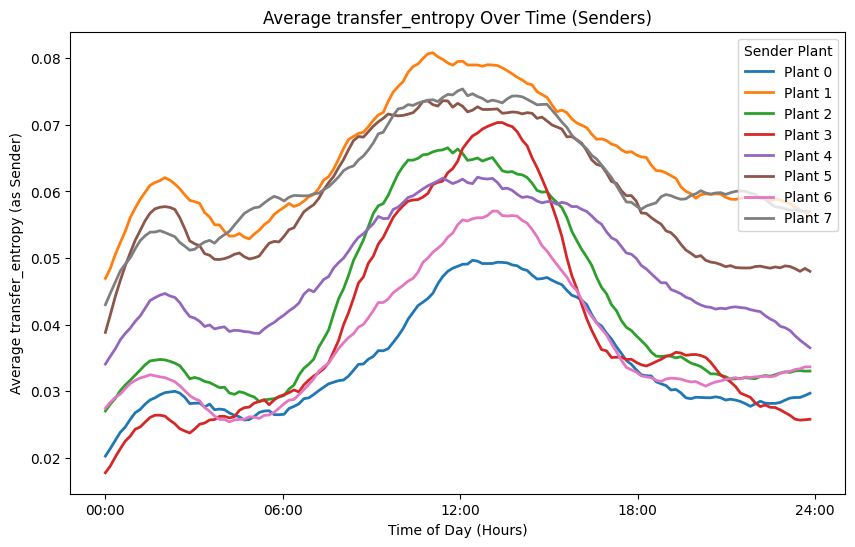

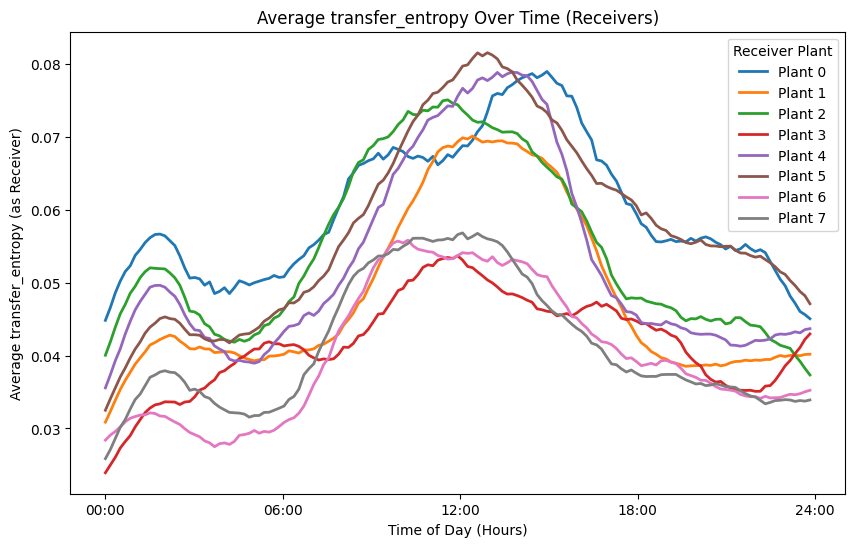

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter  # Import Savitzky-Golay filter

# Reset index to convert MultiIndex into columns for easier plotting
df_plot = df_avg.reset_index()

# Convert "Epoch" to hours of the day (assuming epochs are evenly spaced over 24 hours)
total_epochs = df_plot["Epoch"].max() + 1  # Number of epochs in a full day
df_plot["Hour"] = df_plot["Epoch"] / total_epochs * 24  # Scale to hours (0-24)

# Compute average transfer entropy per sender (Plant1) and per receiver (Plant2)
df_senders = df_plot.groupby(["Epoch", "Plant1"], as_index=False)[metric].mean()
df_receivers = df_plot.groupby(["Epoch", "Plant2"], as_index=False)[metric].mean()

# Rename columns for clarity
df_senders.rename(columns={"Plant1": "Plant"}, inplace=True)
df_receivers.rename(columns={"Plant2": "Plant"}, inplace=True)

# Convert "Epoch" to "Hour"
df_senders["Hour"] = df_senders["Epoch"] / total_epochs * 24
df_receivers["Hour"] = df_receivers["Epoch"] / total_epochs * 24

# Set smoothing parameters (adjust these for desired smoothness)
window_length = 33  # Must be an odd number (increase for more smoothing)
polyorder = 3  # Degree of polynomial (higher for more flexible fitting)

# Get unique plants
plants = sorted(df_plot["Plant1"].unique())  # Ensure consistent order

# Create **one plot for senders**
plt.figure(figsize=(10, 6))
for plant in plants:
    subset = df_senders[df_senders["Plant"] == plant].sort_values(by="Hour")
    if len(subset) >= window_length:  # Ensure enough points for smoothing
        smoothed_entropy = savgol_filter(subset[metric], window_length, polyorder, mode="nearest")
        # use runnig average
        # smoothed_entropy = subset["Transfer Entropy"].rolling(window=window_length, min_periods=1).mean()
    else:
        smoothed_entropy = subset[metric].values  # Use raw values if not enough points
    
    plt.plot(subset["Hour"], smoothed_entropy, label=f"Plant {plant}", linewidth=2)

# Format plot
plt.xlabel("Time of Day (Hours)")
plt.ylabel(f"Average {metric} (as Sender)")
plt.title(f"Average {metric} Over Time (Senders)")
plt.xticks(np.arange(0, 25, 6), labels=["00:00", "06:00", "12:00", "18:00", "24:00"])
plt.legend(title="Sender Plant", loc="upper right")
plt.show()

# Create **one plot for receivers**
plt.figure(figsize=(10, 6))
for plant in plants:
    subset = df_receivers[df_receivers["Plant"] == plant].sort_values(by="Hour")
    if len(subset) >= window_length:  # Ensure enough points for smoothing
        smoothed_entropy = savgol_filter(subset[metric], window_length, polyorder, mode="nearest")
    else:
        smoothed_entropy = subset[metric].values  # Use raw values if not enough points

    plt.plot(subset["Hour"], smoothed_entropy, label=f"Plant {plant}", linewidth=2)

# Format plot
plt.xlabel("Time of Day (Hours)")
plt.ylabel(f"Average {metric} (as Receiver)")
plt.title(f"Average {metric} Over Time (Receivers)")
plt.xticks(np.arange(0, 25, 6), labels=["00:00", "06:00", "12:00", "18:00", "24:00"])
plt.legend(title="Receiver Plant", loc="upper right")
plt.show()


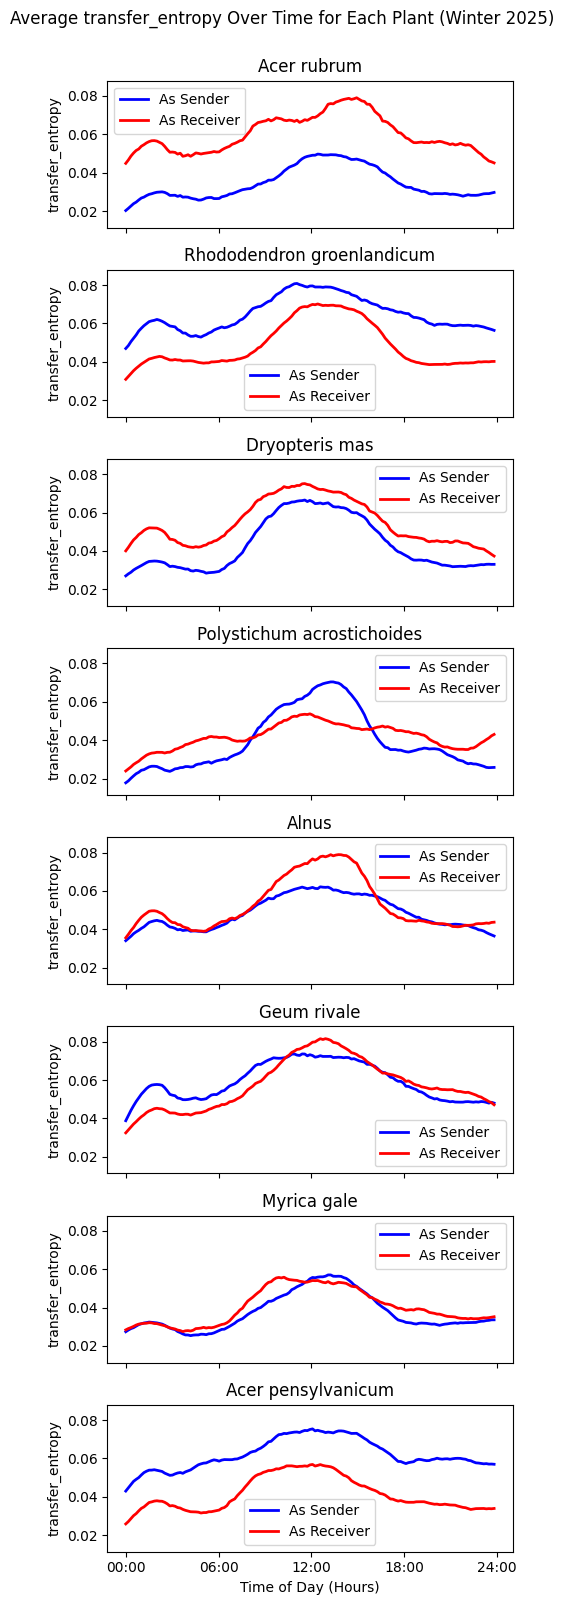

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

# Mapping of plant indices to names
plant_names = {i: name for i, name in enumerate(plant_common_names.keys())}
# List of plants
plants = sorted(df_senders["Plant"].unique())

# Compute global y-axis limits
y_min = float("inf")
y_max = float("-inf")

for plant in plants:
    for df in [df_senders, df_receivers]:
        subset = df[df["Plant"] == plant].sort_values(by="Hour")
        if len(subset) >= window_length:
            smoothed_entropy = savgol_filter(subset[metric], window_length, polyorder, mode="nearest")
        else:
            smoothed_entropy = subset[metric].values
        y_min = min(y_min, smoothed_entropy.min())
        y_max = max(y_max, smoothed_entropy.max())

# Add padding to y-axis limits
y_range = y_max - y_min
y_min -= 0.1 * y_range
y_max += 0.1 * y_range

# Create subplots
fig, axes = plt.subplots(nrows=len(plants), figsize=(5, len(plants) * 2), sharex=True)

for i, plant in enumerate(plants):
    ax = axes[i]
    
    # Process senders
    subset_senders = df_senders[df_senders["Plant"] == plant].sort_values(by="Hour")
    smoothed_sender = (
        savgol_filter(subset_senders[metric], window_length, polyorder, mode="nearest")
        if len(subset_senders) >= window_length else subset_senders[metric].values
    )
    ax.plot(subset_senders["Hour"], smoothed_sender, label="As Sender", color="blue", linewidth=2)

    # Process receivers
    subset_receivers = df_receivers[df_receivers["Plant"] == plant].sort_values(by="Hour")
    smoothed_receiver = (
        savgol_filter(subset_receivers[metric], window_length, polyorder, mode="nearest")
        if len(subset_receivers) >= window_length else subset_receivers[metric].values
    )
    ax.plot(subset_receivers["Hour"], smoothed_receiver, label="As Receiver", color="red", linewidth=2)

    # Format subplot
    ax.set_ylabel(metric)
    ax.set_title(plant_names[plant])  # Use plant name
    ax.legend()
    ax.set_ylim(y_min, y_max)

# Format x-axis
plt.xlabel("Time of Day (Hours)")
plt.xticks(np.arange(0, 25, 6), labels=["00:00", "06:00", "12:00", "18:00", "24:00"])

# Add suptitle with more space
plt.suptitle(f"Average {metric} Over Time for Each Plant (Winter 2025)", y=1.)
plt.tight_layout()
plt.show()


## All seasons

In [29]:
season_mapping

{'Serie 3': 'Spring 2024',
 'Serie 29': 'Summer 2024',
 'Serie 36': 'Fall 2024',
 'Serie 2': 'Winter 2024'}

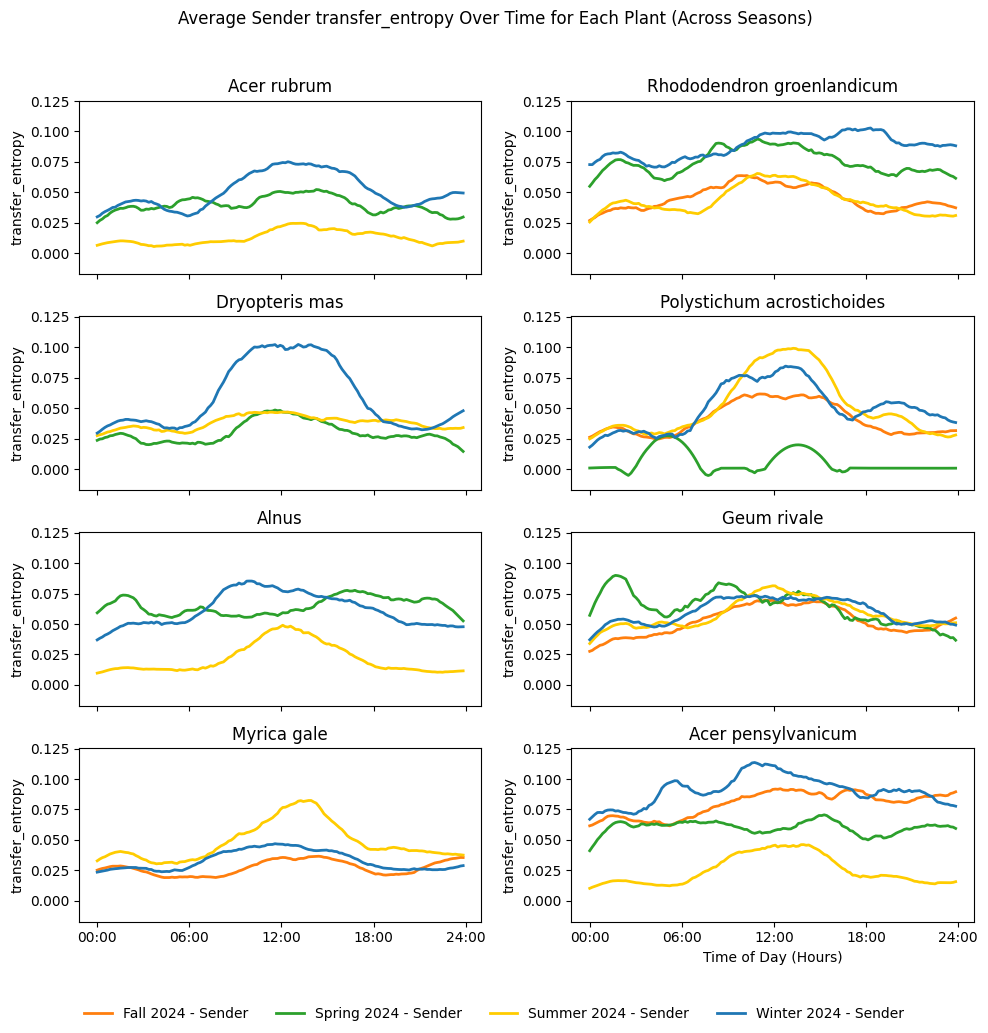

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

plant_names = {i: name for i, name in enumerate(plant_common_names.keys())}
# Mapping of season series to human-readable names
season_mapping = seasons.copy()
# Ensure Season column is mapped correctly
if df_all_seasons_combined["Season"].iloc[0] in season_mapping:
    df_all_seasons_combined["Season"] = df_all_seasons_combined["Season"].map(season_mapping)

# Define season colors
season_colors = {v: c for k, v, c in zip(season_mapping.keys(), season_mapping.values(), ["#2ca02c", "#ffcc00", "#ff7f0e", "#1f77b4"])}

# Smoothing parameters
window_length = 33  # Must be an odd number (adjust for more smoothing)
polyorder = 3  # Degree of polynomial (higher for more flexible fitting)

# Get unique plants and seasons
plants = sorted(df_all_seasons_combined["Plant1"].unique())
seasons = sorted(df_all_seasons_combined["Season"].dropna().unique())

# Compute global y-axis limits across all seasons
y_min, y_max = float("inf"), float("-inf")

for season in seasons:
    df_season = df_all_seasons_combined[df_all_seasons_combined["Season"] == season]

    df_senders = df_season.groupby(["Hour", "Plant1"], as_index=False)[metric].mean()
    df_receivers = df_season.groupby(["Hour", "Plant2"], as_index=False)[metric].mean()

    for df in [df_senders, df_receivers]:
        for plant in plants:
            subset = df[df[df.columns[1]] == plant].sort_values(by="Hour")
            if not subset.empty:  # Avoid empty subsets
                smoothed_entropy = (
                    savgol_filter(subset[metric], window_length, polyorder, mode="nearest")
                    if len(subset) >= window_length else subset[metric].values
                )
                y_min = min(y_min, smoothed_entropy.min())
                y_max = max(y_max, smoothed_entropy.max())

# Add padding to y-axis limits
y_range = y_max - y_min
y_min -= 0.1 * y_range
y_max += 0.1 * y_range

# Create subplots: 2 columns, automatic number of rows
n_cols = 2
n_rows = -(-len(plants) // n_cols)  # Equivalent to math.ceil(len(plants) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, n_rows * 2.5), sharex=True)
axes = axes.flatten()  # Convert to 1D array for easier indexing

for i, plant in enumerate(plants):
    ax = axes[i]

    for season in seasons:
        df_season = df_all_seasons_combined[df_all_seasons_combined["Season"] == season]

        df_senders = df_season.groupby(["Hour", "Plant1"], as_index=False)[metric].mean()
        df_receivers = df_season.groupby(["Hour", "Plant2"], as_index=False)[metric].mean()

        color = season_colors[season]

        # Process senders
        subset_senders = df_senders[df_senders["Plant1"] == plant].sort_values(by="Hour")
        if not subset_senders.empty:
            smoothed_sender = (
                savgol_filter(subset_senders[metric], window_length, polyorder, mode="nearest")
                if len(subset_senders) >= window_length else subset_senders[metric].values
            )
            ax.plot(subset_senders["Hour"], smoothed_sender, label=f"{season} - Sender", color=color, linestyle="-", linewidth=2)

        # Process receivers
        subset_receivers = df_receivers[df_receivers["Plant2"] == plant].sort_values(by="Hour")
        # if not subset_receivers.empty:
        #     smoothed_receiver = (
        #         savgol_filter(subset_receivers["Transfer Entropy"], window_length, polyorder, mode="nearest")
        #         if len(subset_receivers) >= window_length else subset_receivers["Transfer Entropy"].values
        #     )
        #     ax.plot(subset_receivers["Hour"], smoothed_receiver, label=f"{season} - Receiver", color=color, linestyle="--", linewidth=2)

    # Format subplot
    ax.set_ylabel(metric)
    ax.set_title(plant_names[plant])
    ax.set_ylim(y_min, y_max)

# Remove empty subplots if the number of plants is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Format x-axis
plt.xlabel("Time of Day (Hours)")
plt.xticks(np.arange(0, 25, 6), labels=["00:00", "06:00", "12:00", "18:00", "24:00"])

# Add single legend below all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=10, frameon=False)

# Adjust layout
plt.suptitle(f"Average Sender {metric} Over Time for Each Plant (Across Seasons)", y=1.02)
plt.tight_layout(rect=[0, 0.05, 1, 1])  # Make space for legend
plt.show()


## Graph (to do)

In [ ]:
# Sum transfer entropy per plant (as a sender)
df_sender = df_avg.groupby("Plant1")["Transfer Entropy"].sum().sort_values(ascending=False)

# Sum transfer entropy per plant (as a receiver)
df_receiver = df_avg.groupby("Plant2")["Transfer Entropy"].sum().sort_values(ascending=False)

print("Most influential plants (senders):\n", df_sender)
print("Most influenced plants (receivers):\n", df_receiver)


Most influential plants (senders):
 Plant1
4    89.806300
7    75.705200
3    69.712149
6    61.190010
5    59.885581
2    59.650150
0    51.052299
1    50.301026
Name: Transfer Entropy, dtype: float64
Most influenced plants (receivers):
 Plant2
2    95.118446
0    90.619902
3    66.618638
5    62.986605
7    60.823468
1    59.588469
4    43.363904
6    38.183281
Name: Transfer Entropy, dtype: float64


In [ ]:
# Sum transfer entropy per plant pair
df_pairs = df_avg.groupby(["Plant1", "Plant2"])["Transfer Entropy"].sum().sort_values(ascending=False)

print("Strongest plant-to-plant interactions:\n", df_pairs.head(10))


Strongest plant-to-plant interactions:
 Plant1  Plant2
4       2         18.281732
        0         16.532861
7       2         16.024855
3       2         15.100745
7       0         14.169872
3       0         13.999335
4       3         13.992817
2       0         13.594779
4       7         13.488263
5       2         12.596934
Name: Transfer Entropy, dtype: float64


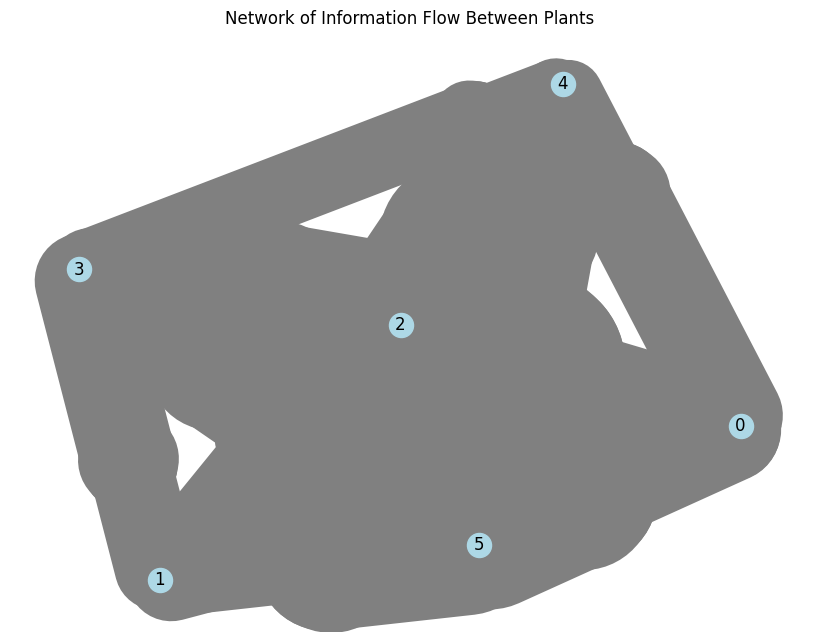

In [ ]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add edges from df_results
for (plant1, plant2), entropy in df_results.groupby(["Plant1", "Plant2"])["Transfer Entropy"].sum().items():
    if entropy > 0:  # Only include meaningful interactions
        G.add_edge(plant1, plant2, weight=entropy)

# Draw network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G)  # Layout for positioning nodes
nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray", width=[d["weight"]*10 for (_, _, d) in G.edges(data=True)])
plt.title("Network of Information Flow Between Plants")
plt.show()


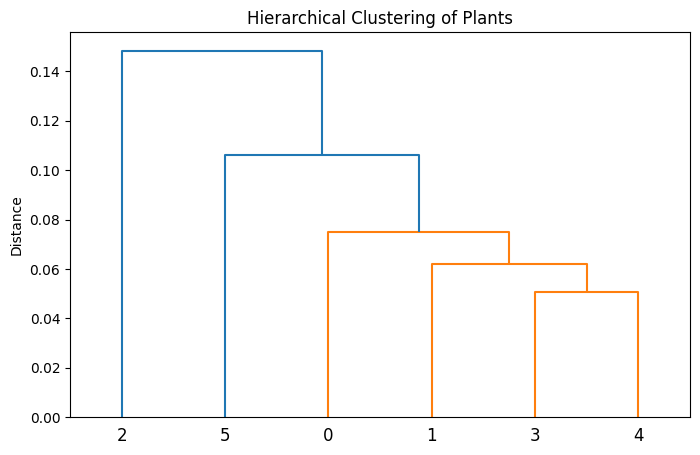

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Pivot table for clustering
df_cluster = df_results.pivot_table(index="Plant1", columns="Plant2", values="Transfer Entropy", fill_value=0)

# Perform clustering
linked = linkage(df_cluster, method="ward")

# Plot dendrogram
plt.figure(figsize=(8, 5))
dendrogram(linked, labels=df_cluster.index, orientation="top")
plt.title("Hierarchical Clustering of Plants")
plt.ylabel("Distance")
plt.show()


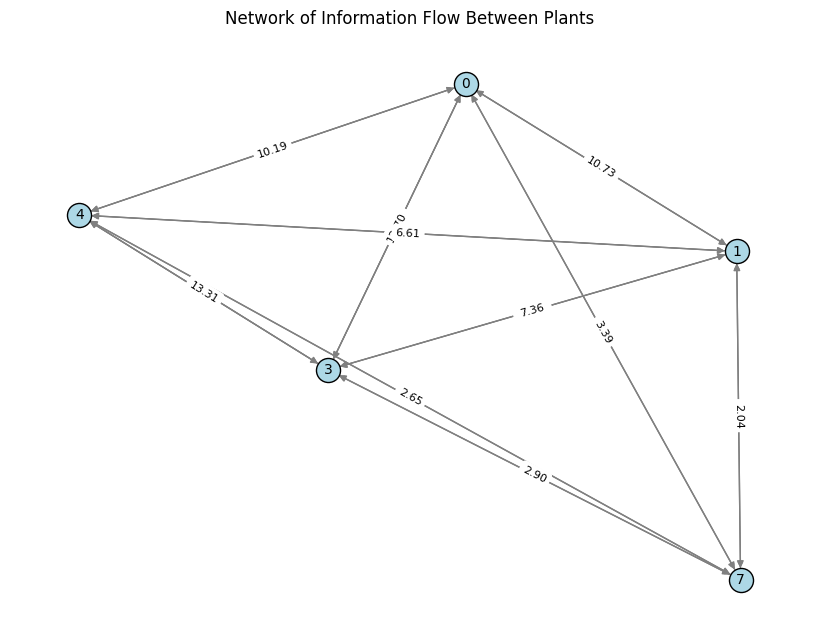

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add edges for transfer entropy (information flow)
for (plant1, plant2), entropy in df_results.groupby(["Plant1", "Plant2"])["Transfer Entropy"].sum().items():
    if entropy > 0:  # Only include meaningful interactions
        G.add_edge(plant1, plant2, weight=entropy)

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)  # Layout for positioning nodes
edges = G.edges(data=True)

# Draw nodes
nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray", font_size=10, edgecolors="black")

# Draw edges with width proportional to entropy
nx.draw_networkx_edges(G, pos, width=[d["weight"] * 0.05 for (_, _, d) in edges], edge_color="gray")

# Add edge labels for transfer entropy values
edge_labels = {(i, j): f"{d['weight']:.2f}" for i, j, d in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Network of Information Flow Between Plants")
plt.show()

# =============================
# Time-based Analysis: Evolution of Information Flow Over Epochs
# =============================




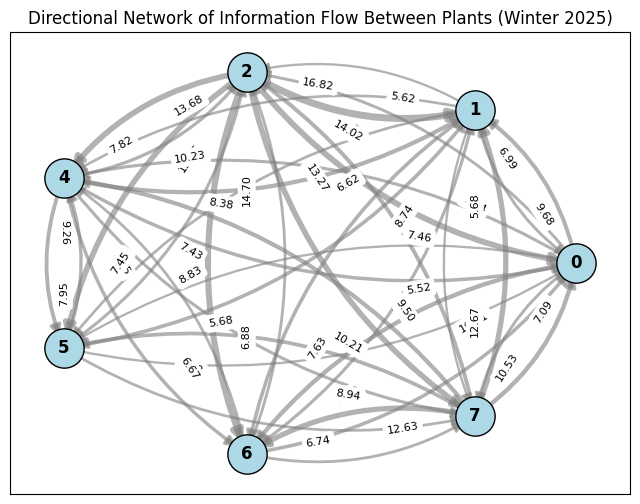

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add edges for transfer entropy (information flow)
for (plant1, plant2), entropy in df_avg.groupby(["Plant1", "Plant2"])["Transfer Entropy"].sum().items():
    if entropy > 0:  # Only include meaningful interactions
        G.add_edge(plant1, plant2, weight=entropy)

# Adjust positions to avoid overlap
pos = nx.circular_layout(G)  # Circular layout reduces edge overlap

# Create figure
plt.figure(figsize=(8, 6))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color="lightblue", edgecolors="black", node_size=800)

# Draw directional edges with curved arrows to avoid overlap
edge_weights = [d["weight"] * 0.3 for (_, _, d) in G.edges(data=True)]
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=edge_weights, alpha=0.6,
                       edge_color="gray", arrows=True, arrowsize=15, connectionstyle="arc3,rad=0.2")

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold")

# Add edge labels (transfer entropy values)
edge_labels = {(i, j): f"{d['weight']:.2f}" for i, j, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, label_pos=0.3)

plt.title("Directional Network of Information Flow Between Plants (Winter 2025)")
plt.show()
